In [3]:
import pickle
import hdbscan
import umap
import matplotlib.pyplot as plt
import numpy as np

c:\Users\prash\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
embeddings_file = "embeddings.pkl" 
sentences_file = "sentences.txt"


In [15]:
sentences = []
with open(sentences_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            sentences.append(line)
 

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 5944: character maps to <undefined>

In [7]:
# load embeddings
with open(embeddings_file, 'rb') as f:
    embeddings = pickle.load(f)
 
# convert to numpy array just in case
embeddings = np.array(embeddings)

In [8]:
embeddings = np.array(embeddings)

In [9]:
sentences = sentences[:100]
embeddings = embeddings[:100]

In [10]:
print(f"loaded {len(sentences)} sentences")
print(f"embedding shape: {embeddings.shape}")

loaded 100 sentences
embedding shape: (100, 384)


In [12]:
reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

c:\Users\prash\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
print("clustering...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric='euclidean')
labels = clusterer.fit_predict(embeddings_2d)
 
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
num_noise = list(labels).count(-1)
print(f"found {num_clusters} clusters")
print(f"noise points (unclustered): {num_noise}")

clustering...
found 9 clusters
noise points (unclustered): 33


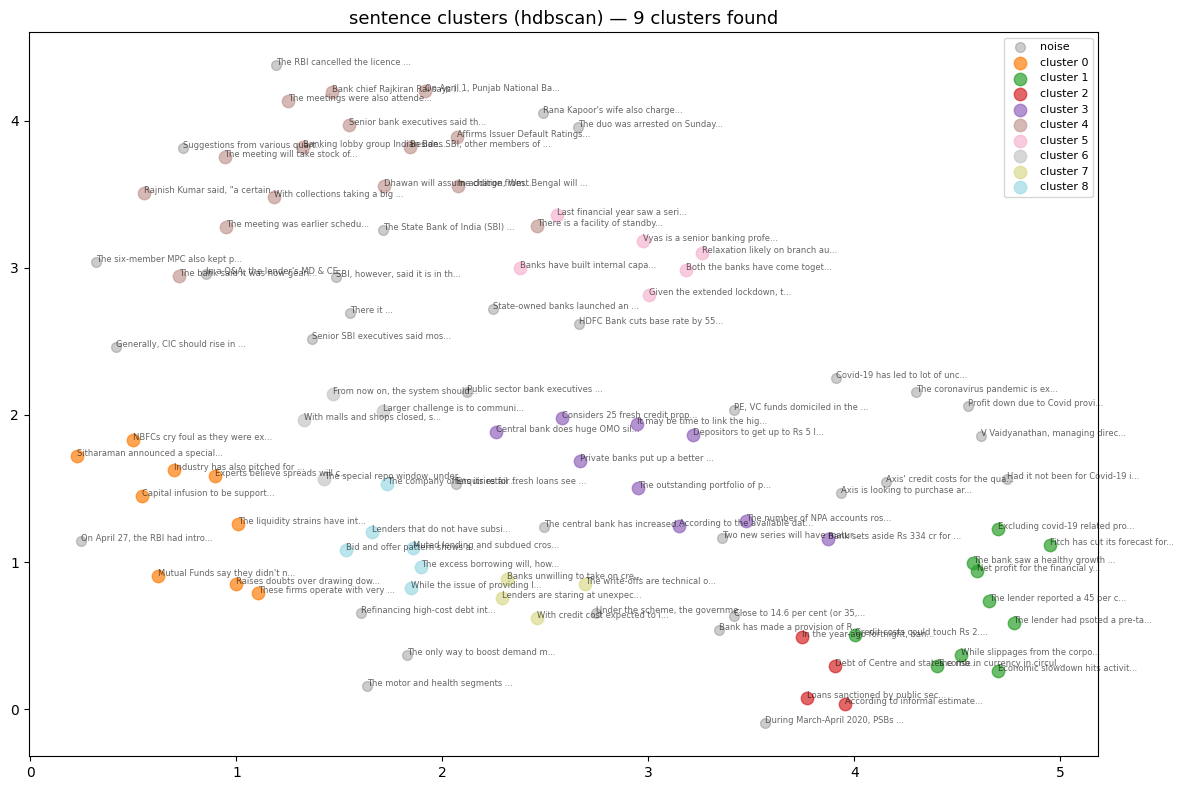

saved plot to clusters.png

--- cluster contents ---

[noise / unclustered]
  - Close to 14.6 per cent (or 35,000) of the 240,000 ATMs in India are new-age recyclers, even though they have been around for only ...
  - V Vaidyanathan, managing director and chief executive, will take 30 per cent cut in his compensation, including fixed ...
  - Rana Kapoor's wife also charged with abetting crime
  - Under the scheme, the government will offer 100 per cent guarantee on loans.
  - HDFC Bank cuts base rate by 55 bps; SBI calls ALCO meeting to take call
  - The six-member MPC also kept policy stance unchanged at 'accommodative' for "as long as necessary" to revive growth
  - The central bank has increased group exposure limits of lenders from 25% to 30%
  - Two new series will have maturities of April 2025 and April 2031.
  - Enquiries for fresh loans see uptick
  - In a Q&A, the lender's MD & CEO, Amitabh Chaudhry, also dwells on the stimulus package announced by the government, and risk ...

In [ ]:
 

plt.figure(figsize=(12, 8))
 

unique_labels = sorted(set(labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
 
for label, color in zip(unique_labels, colors):
    mask = labels == label
    
    if label == -1:
        # noise points in grey
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    c='grey', s=50, alpha=0.4, label='noise')
    else:
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    color=color, s=80, alpha=0.7, label=f'cluster {label}')

for i, sentence in enumerate(sentences):
    short = sentence[:30] + "..." if len(sentence) > 30 else sentence
    plt.annotate(short, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=6, alpha=0.6)
 
plt.title(f'sentence clusters (hdbscan) — {num_clusters} clusters found', fontsize=13)
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig("clusters.png", dpi=150)
plt.show()
print("saved plot to clusters.png")
 
print("\n--- cluster contents ---")
for label in sorted(set(labels)):
    if label == -1:
        print(f"\n[noise / unclustered]")
    else:
        print(f"\n[cluster {label}]")
    
    for i, l in enumerate(labels):
        if l == label:
            print(f"  - {sentences[i]}")
 